IMPORT LIBRARIES

In [2]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.7 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

import warnings
warnings.filterwarnings('ignore')

LOAD DATA

In [4]:
df = pd.read_csv('ecommerce_sales_data.csv')

df.head()

,Order Date,Product Name,Category,Region,Quantity,Sales,Profit
0,2024-12-31,Printer,Office,North,4,3640,348.93
1,2022-11-27,Mouse,Accessories,East,7,1197,106.53
2,2022-05-11,Tablet,Electronics,South,5,5865,502.73
3,2024-03-16,Mouse,Accessories,South,2,786,202.87
4,2022-09-10,Mouse,Accessories,West,1,509,103.28


DATA PREPROCESSING

Convert date

In [5]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

Handle missing values

In [7]:
df = df.dropna()

Feature Engineering

In [8]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Day'] = df['Order Date'].dt.day
df['DayOfWeek'] = df['Order Date'].dt.dayofweek
df['Quarter'] = df['Order Date'].dt.quarter

Profit Margin

In [9]:
df['Profit_Margin'] = df['Profit'] / df['Sales']

EXPLORATORY DATA ANALYSIS

Sales Trend Over Time

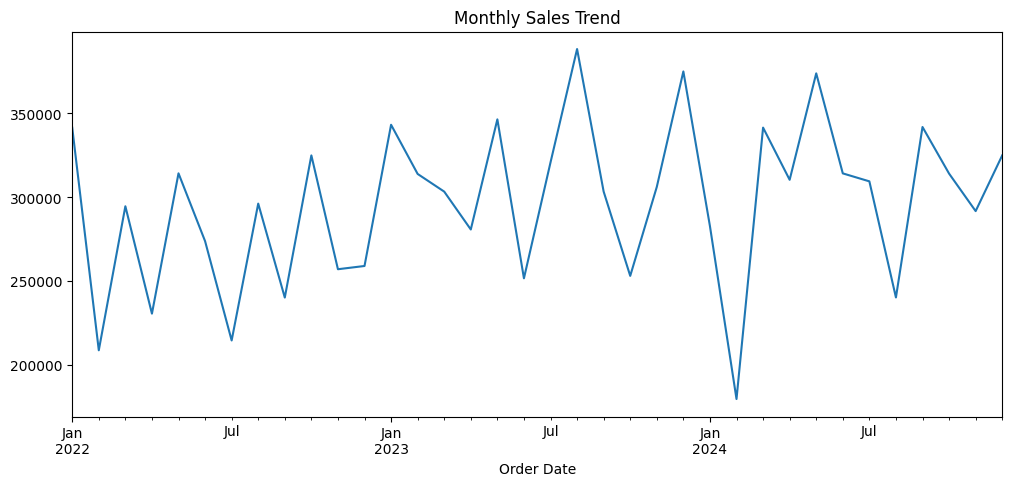

In [10]:
monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()

monthly_sales.plot(figsize=(12,5), title='Monthly Sales Trend')
plt.show()

Profit Trend

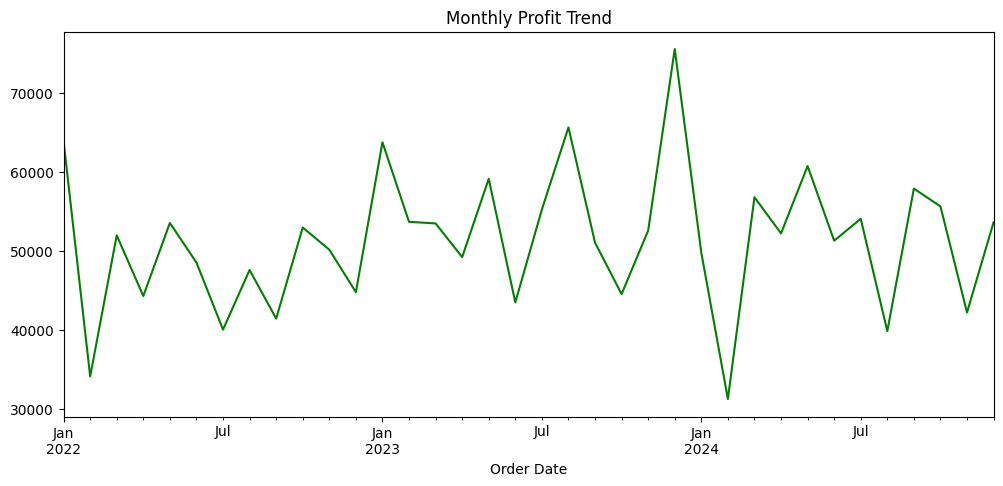

In [11]:
monthly_profit = df.groupby(df['Order Date'].dt.to_period('M'))['Profit'].sum()

monthly_profit.plot(figsize=(12,5), color='green', title='Monthly Profit Trend')
plt.show()

Category Performance

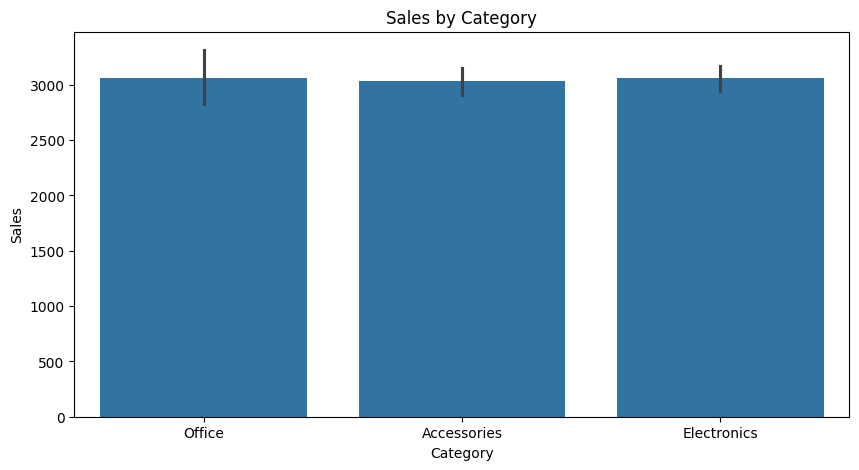

In [12]:
plt.figure(figsize=(10,5))
sns.barplot(x='Category', y='Sales', data=df)
plt.title("Sales by Category")
plt.show()

Region Analysis

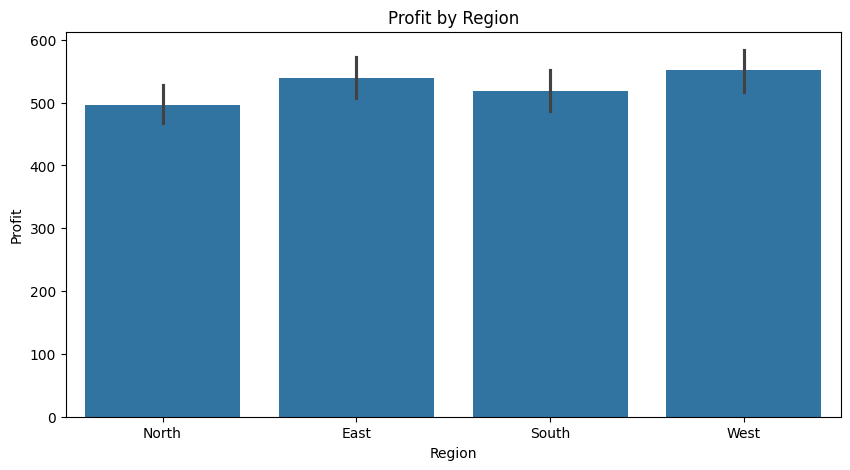

In [13]:
plt.figure(figsize=(10,5))
sns.barplot(x='Region', y='Profit', data=df)
plt.title("Profit by Region")
plt.show()

Seasonality Heatmap

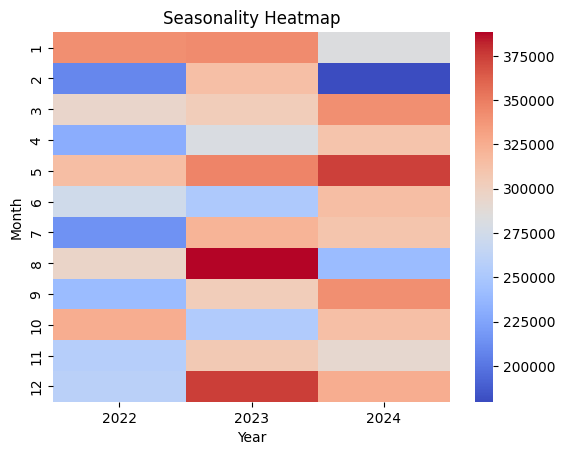

In [14]:
pivot = df.pivot_table(values='Sales', index='Month', columns='Year', aggfunc='sum')

sns.heatmap(pivot, cmap='coolwarm')
plt.title("Seasonality Heatmap")
plt.show()

Correlation Analysis

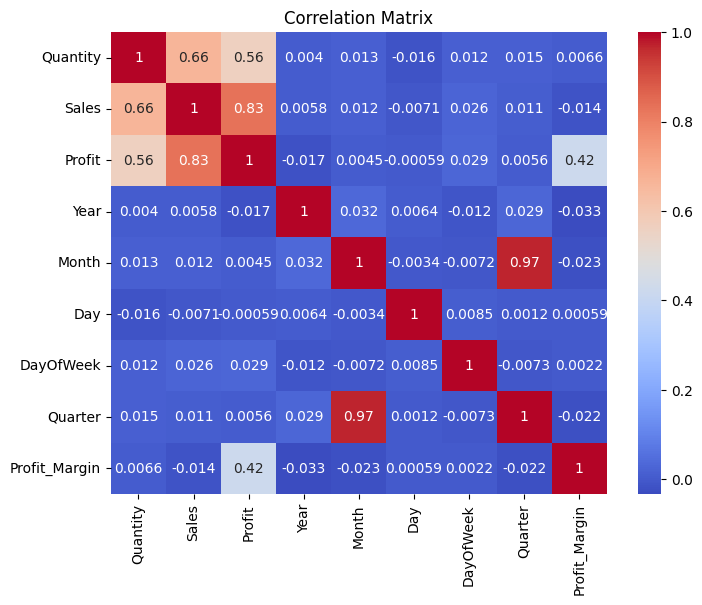

In [15]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

DATA PREPARATION FOR ML

Encode categorical variables

In [16]:
le_category = LabelEncoder()
le_region = LabelEncoder()

df['Category'] = le_category.fit_transform(df['Category'])
df['Region'] = le_region.fit_transform(df['Region'])

Features & Target

In [17]:
X = df[['Category', 'Region', 'Quantity', 'Month', 'Year', 'DayOfWeek', 'Quarter']]
y_sales = df['Sales']
y_profit = df['Profit']

Train-Test Split

In [18]:
X_train, X_test, y_train_s, y_test_s = train_test_split(X, y_sales, test_size=0.2, random_state=42)
X_train, X_test, y_train_p, y_test_p = train_test_split(X, y_profit, test_size=0.2, random_state=42)

MACHINE LEARNING MODELS

XGBoost

In [19]:
xgb = XGBRegressor()
xgb.fit(X_train, y_train_s)

pred_xgb = xgb.predict(X_test)

LightGBM

In [20]:
lgb = LGBMRegressor()
lgb.fit(X_train, y_train_s)

pred_lgb = lgb.predict(X_test)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000358 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 46
[LightGBM] [Info] Number of data points in the train set: 2800, number of used features: 7
[LightGBM] [Info] Start training from score 3013.597857


CatBoost

In [21]:
cat = CatBoostRegressor(verbose=0)
cat.fit(X_train, y_train_s)

pred_cat = cat.predict(X_test)

MODEL EVALUATION

In [22]:
def evaluate(y_true, y_pred, name):
    print(f"\n{name}")
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("R2:", r2_score(y_true, y_pred))

In [23]:
evaluate(y_test_s, pred_xgb, "XGBoost")
evaluate(y_test_s, pred_lgb, "LightGBM")
evaluate(y_test_s, pred_cat, "CatBoost")


XGBoost
MAE: 1680.563232421875
RMSE: 2314.756358669309
R2: 0.14597207307815552

LightGBM
MAE: 1501.2991455277986
RMSE: 1997.7993818067234
R2: 0.36384154363001386

CatBoost
MAE: 1533.1797982870066
RMSE: 2056.4101237546033
R2: 0.3259672133195536


MODEL COMPARISON TABLE

In [24]:
results = pd.DataFrame({
    'Model': ['XGBoost', 'LightGBM', 'CatBoost'],
    'MAE': [
        mean_absolute_error(y_test_s, pred_xgb),
        mean_absolute_error(y_test_s, pred_lgb),
        mean_absolute_error(y_test_s, pred_cat)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test_s, pred_xgb)),
        np.sqrt(mean_squared_error(y_test_s, pred_lgb)),
        np.sqrt(mean_squared_error(y_test_s, pred_cat))
    ],
    'R2': [
        r2_score(y_test_s, pred_xgb),
        r2_score(y_test_s, pred_lgb),
        r2_score(y_test_s, pred_cat)
    ]
})

results

,Model,MAE,RMSE,R2
0,XGBoost,1680.563232,2314.756359,0.145972
1,LightGBM,1501.299146,1997.799382,0.363842
2,CatBoost,1533.179798,2056.410124,0.325967


Feature Importance

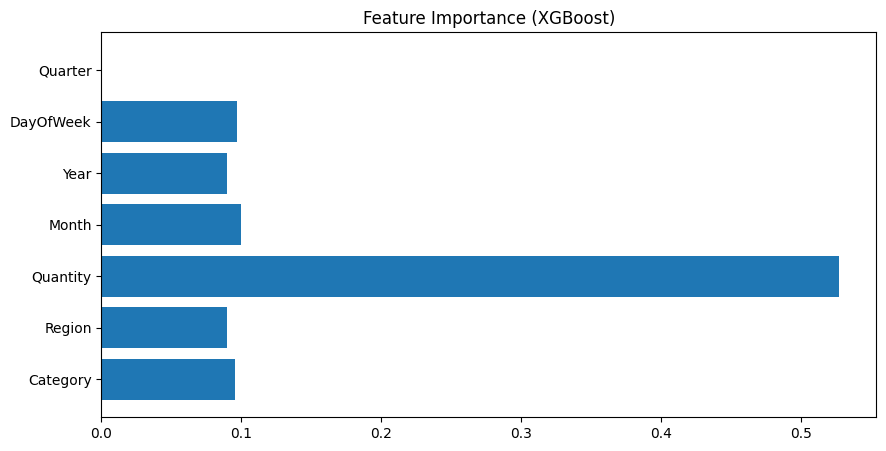

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.barh(X.columns, xgb.feature_importances_)
plt.title("Feature Importance (XGBoost)")
plt.show()

RUN PREDICTION ON TEST DATA

In [28]:
y_pred = xgb.predict(X_test)

SEE ACTUAL VS PREDICTED

In [29]:
comparison = pd.DataFrame({
    'Actual': y_test_s.values,
    'Predicted': y_pred
})

comparison.head(10)

,Actual,Predicted
0,3625,2475.038086
1,5160,3590.928711
2,355,599.504883
3,3136,2825.218262
4,3648,4567.727051
5,504,399.748627
6,2142,4878.805664
7,1800,7407.862793
8,907,282.617157
9,4656,2425.726807


VISUAL TEST

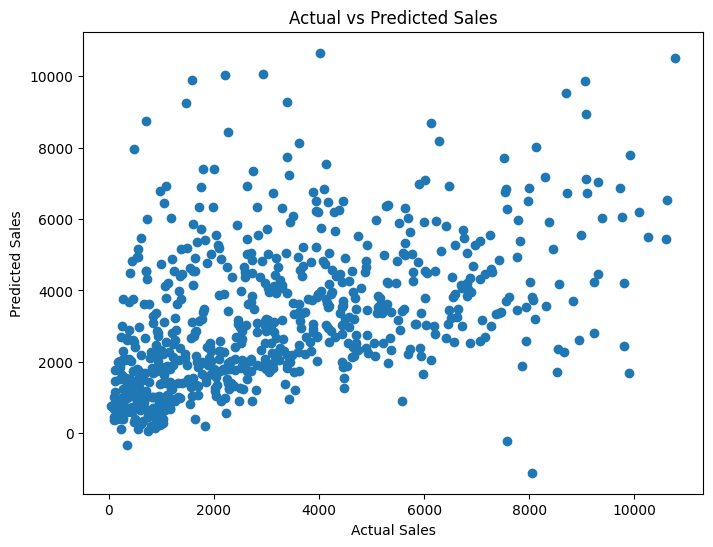

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test_s, y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()

ERROR DISTRIBUTION

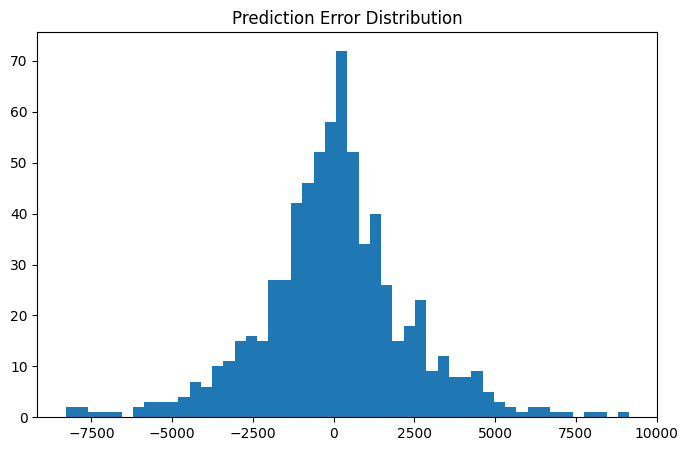

In [32]:
errors = y_test_s - y_pred

plt.figure(figsize=(8,5))
plt.hist(errors, bins=50)
plt.title("Prediction Error Distribution")
plt.show()

METRICS

In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE:", mean_absolute_error(y_test_s, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test_s, y_pred)))
print("R2 Score:", r2_score(y_test_s, y_pred))

MAE: 1680.563232421875
RMSE: 2314.756358669309
R2 Score: 0.14597207307815552


cross-validation

In [36]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(xgb, X, y_sales, cv=5, scoring='r2')

print("Cross-validation R2:", scores)
print("Average R2:", scores.mean())

Cross-validation R2: [0.20315504 0.15604961 0.24125844 0.18830431 0.0927155 ]
Average R2: 0.17629657983779906
